In [1]:
# PyTorch core components
import torch
import torch.nn as nn
import torch.optim as optim

# Learning rate scheduler
from torch.optim.lr_scheduler import StepLR

# Data utilities
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision

# Logging and visualization
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

# Utility libraries
import numpy as np
import random
import os


### Model

In [2]:
class DNN(nn.Module):
    def __init__(self, num_classes):
        super(DNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 512)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(512, 128)
        self.relu = nn.ReLU()
        self.fc4 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

In [3]:
# -------------------------
# Squeeze-and-Excitation Block
# -------------------------
# This block recalibrates channel-wise features by:
# 1. Globally pooling the spatial dimensions to compute channel descriptors.
# 2. Passing the descriptors through a small fully connected network.
# 3. Scaling the original features using the resulting channel weights.
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super(SEBlock, self).__init__()
        # Global average pooling to create channel descriptors (shape: B x C x 1 x 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        # Two fully connected layers with a bottleneck to reduce parameters
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()  # Output scale factors in range [0, 1]
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze: Reduce spatial dimensions
        y = self.pool(x).view(b, c)
        # Excite: Generate channel-wise weights
        y = self.fc(y).view(b, c, 1, 1)
        # Scale the input features
        return x * y.expand_as(x)

In [4]:
# -------------------------
# Base Convolutional Network
# -------------------------
# The network is built using depthwise separable convolution blocks.
# - Depthwise convolution: Processes each input channel separately.
# - Pointwise convolution: Mixes the channels via 1x1 convolutions.
# Optional SE blocks can be attached to recalibrate channel responses.
class BaseConvNet(nn.Module):
    def __init__(self, num_classes=10, channels=(12, 24, 48)):
        """
        Args:
            num_classes (int): Number of output classes.
            channels (tuple): Tuple defining the number of channels at each stage.
                              Expected format: (channels_stage1, channels_stage2, channels_stage3)
        """
        super(BaseConvNet, self).__init__()

        # Utility function: Create a depthwise separable convolution block.
        # Optionally adds an SE block if use_se is True.
        def dw_conv(in_channels, out_channels, use_se=False):
            layers = [
                # Depthwise convolution: one filter per channel.
                nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(inplace=True),
                # Pointwise convolution: 1x1 convolution to mix channels.
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ]
            if use_se:
                layers.append(SEBlock(out_channels))
            return nn.Sequential(*layers)
        
        # First Stage:
        # Increase from 1 input channel (grayscale) to channels[0].
        # Apply an SE block to recalibrate early features.
        self.layer1 = dw_conv(1, channels[0], use_se=True)    # Output: (channels[0] x 28 x 28)
        self.pool1 = nn.MaxPool2d(2)  # Downsample: 28x28 -> 14x14

        # Second Stage:
        # Increase from channels[0] to channels[1], plus an extra block for additional refinement.
        self.layer2 = dw_conv(channels[0], channels[1], use_se=True)
        self.layer2_extra = dw_conv(channels[1], channels[1], use_se=False)
        self.pool2 = nn.MaxPool2d(2)  # Downsample: 14x14 -> 7x7

        # Third Stage:
        # Increase from channels[1] to channels[2] with an SE block.
        self.layer3 = dw_conv(channels[1], channels[2], use_se=True)
        
        # Global Pooling:
        # Reduce each feature map to a single value (1x1).
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Classifier:
        # Flattens the features, applies dropout, and outputs the class scores.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(channels[2], num_classes)
        )

    def forward(self, x):
        # Pass input through Stage 1 and downsample.
        x = self.layer1(x)
        x = self.pool1(x)
        # Pass input through Stage 2 (main branch and extra block) and downsample.
        x = self.layer2(x)
        x = self.layer2_extra(x)
        x = self.pool2(x)
        # Pass input through Stage 3 and apply global pooling.
        x = self.layer3(x)
        x = self.global_pool(x)
        # Final classification.
        x = self.classifier(x)
        return x

In [5]:
# -------------------------
# Dataset-Specific Models
# -------------------------
# These subclasses define models for different datasets by adjusting the channel counts.
class MNISTConvNet(BaseConvNet):
    def __init__(self, num_classes=10):
        # MNIST: Less complex images, smaller capacity is sufficient.
        channels = (8, 16, 32) # (12, 24, 48)
        super(MNISTConvNet, self).__init__(num_classes=num_classes, channels=channels)

class KMNISTConvNet(BaseConvNet):
    def __init__(self, num_classes=10):
        # KMNIST: Slightly more complex than MNIST; use moderate capacity.
        channels = (12, 24, 48) # (12, 24, 48) # (16, 32, 64) # (24, 48, 96)
        super(KMNISTConvNet, self).__init__(num_classes=num_classes, channels=channels)

class FashionMNISTConvNet(BaseConvNet):
    def __init__(self, num_classes=10):
        # FashionMNIST: More variation and complexity; higher capacity is beneficial.
        channels = (12, 24, 48) # (16, 32, 64) # (24, 48, 96)
        super(FashionMNISTConvNet, self).__init__(num_classes=num_classes, channels=channels)

### Load dataset

In [6]:
def get_transforms(augment=False):
    if augment:
        return transforms.Compose([
            transforms.RandomAffine(
                degrees=10,            # Use a smaller rotation range (±10°)
                translate=(0.05, 0.05),# Reduce translation to 5% of the image's width/height
                scale=(0.95, 1.05)     # Use a tighter scaling range (95% to 105%)
            ),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    else:
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

In [7]:
data_dir = '/home/wins057/Documents/Projects/python-for-dl-homework/week06/data'

# Load the dataset
# Supports MNIST, FashionMNIST, KMNIST, and EMNIST
def load_data(dataset_name, batch_size=64, augment=False):
    transform = get_transforms(augment)

    if dataset_name == "MNIST":
        train_set = datasets.MNIST(root=data_dir, train=True, transform=transform, download=True)
        test_set = datasets.MNIST(root=data_dir, train=False, transform=transform, download=True)
    elif dataset_name == "FashionMNIST":
        train_set = datasets.FashionMNIST(root=data_dir, train=True, transform=transform, download=True)
        test_set = datasets.FashionMNIST(root=data_dir, train=False, transform=transform, download=True)
    elif dataset_name == "KMNIST":
        train_set = datasets.KMNIST(root=data_dir, train=True, transform=transform, download=True)
        test_set = datasets.KMNIST(root=data_dir, train=False, transform=transform, download=True)
    elif dataset_name == "EMNIST":
        train_set = datasets.EMNIST(root=data_dir, split='balanced', train=True, transform=transform, download=True)
        test_set = datasets.EMNIST(root=data_dir, split='balanced', train=False, transform=transform, download=True)
    else:
        raise ValueError("Unsupported dataset name.")
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

### Parameters Count

In [8]:
def count_parameters(model):
    """Count the number of trainable parameters in the model.
    Args:
        model (nn.Module): The model to count parameters for.
    Returns:
        int: The number of trainable parameters.
    """
    # Count the number of parameters that require gradients
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
model = DNN(num_classes=10)
print(f"{count_parameters(model)} parameters in DNN model")
model = MNISTConvNet(num_classes=10)
print(f"{count_parameters(model)} parameters in MNISTConvNet model")
model = KMNISTConvNet(num_classes=10)
print(f"{count_parameters(model)} parameters in KMNISTConvNet model")
model = FashionMNISTConvNet(num_classes=10)
print(f"{count_parameters(model)} parameters in FashionMNISTConvNet model")

731530 parameters in DNN model
2501 parameters in MNISTConvNet model
4917 parameters in KMNISTConvNet model
4917 parameters in FashionMNISTConvNet model


### Train and Evaluate Function

In [10]:
# Evaluate the model
# Computes accuracy on test set
def evaluate_model(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [11]:
def format_lr(lr: float) -> str:
    """
    Format the learning rate by removing trailing zeros.
    
    Examples:
      0.001000 -> 0.001
      0.010000 -> 0.01
    """
    return f"{lr:.6f}".rstrip('0').rstrip('.')

In [12]:
def log_tensorboard(writer, model, train_loader, dataset_name):
    example_images, _ = next(iter(train_loader))
    writer.add_graph(model, example_images.to(next(model.parameters()).device))
    img_grid = torchvision.utils.make_grid(example_images[:16])
    writer.add_image(f"{dataset_name}_examples", img_grid)

In [13]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, writer, epoch, log_interval=100):
    """
    Train the model for one epoch and log intermediate metrics.

    Args:
        model: The model to train.
        train_loader: DataLoader for training data.
        criterion: Loss function.
        optimizer: Optimizer for model parameters.
        device: torch.device (e.g. 'cuda' or 'cpu').
        writer: TensorBoard SummaryWriter.
        epoch: Current epoch index.
        log_interval: Number of batches between logging.

    Returns:
        train_accuracy: Training accuracy for the epoch.
    """
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        global_step = epoch * len(train_loader) + batch_idx
        # Log every log_interval batches
        if (batch_idx + 1) % log_interval == 0:
            writer.add_scalar("Loss/Train", running_loss / log_interval, global_step)
            running_loss = 0.0
            # Optionally log histograms for parameters
            for name, param in model.named_parameters():
                writer.add_histogram(name, param, global_step)
                
    train_accuracy = correct / total
    return train_accuracy

In [14]:
from dataclasses import dataclass, field

@dataclass
class TrainingConfig:
    dataset_name: str = "MNIST"
    epochs: int = 10
    lr: float = 0.001
    scheduler_params: dict = field(default_factory=lambda: {"step_size": 45, "gamma": 0.5})
    log_dir: str = "runs"
    checkpoint_interval: int = 10
    dnn_model: bool = False  # Flag to use DNN model instead of ConvNet
    batch_size: int = 64
    augment: bool = True  # Flag to apply data augmentation

In [15]:
def train_model(model, train_loader, test_loader, config: TrainingConfig):
    """
    Trains the model and saves the best model based on validation accuracy.
    Logs training metrics using TensorBoard and prints the learning rate changes.
    
    Args:
        model: The model to be trained.
        train_loader: DataLoader for training data.
        test_loader: DataLoader for validation/testing data.
        config: TrainingConfig object containing training parameters.
    
    Returns:
        model: The trained model loaded with the best checkpoint.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.lr)
    scheduler = StepLR(optimizer, **config.scheduler_params)
    
    writer = SummaryWriter(os.path.join(config.log_dir, config.dataset_name))
    log_tensorboard(writer, model, train_loader, config.dataset_name)
    
    checkpoint_dir = os.path.join("checkpoints", config.dataset_name, model.__class__.__name__)
    os.makedirs(checkpoint_dir, exist_ok=True)
    saved_model_accs = {}
    
    for epoch in range(config.epochs):
        # Print the current learning rate at the beginning of each epoch
        current_lr = optimizer.param_groups[0]['lr']
        
        # Train for one epoch
        train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, writer, epoch)
        val_acc = evaluate_model(model, test_loader, device)
        
        writer.add_scalars("Accuracy", {"Train": train_acc, "Validation": val_acc}, epoch)
        print(f"[{config.dataset_name}] Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, LR={format_lr(current_lr)}")

        # Decay the learning rate and check if it changes
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr < old_lr:
            print(f"🔻Learning rate decayed from {format_lr(old_lr)} to {format_lr(new_lr)} at epoch {epoch+1}")

        # Save checkpoint every checkpoint_interval epochs
        if (epoch + 1) % config.checkpoint_interval == 0:
            filename = f"epoch_{epoch+1}.pth"
            save_path = os.path.join(checkpoint_dir, filename)
            torch.save(model.state_dict(), save_path)
            saved_model_accs[filename] = val_acc
            print(f"📦 Saved model to {filename} with accuracy {val_acc:.4f}")
    
    print(f"\n📊 Checkpoints and Accuracies: \n{saved_model_accs}")
    
    # Select and save the best model based on validation accuracy
    if saved_model_accs:
        best_filename = max(saved_model_accs, key=lambda k: saved_model_accs[k])
        best_acc = saved_model_accs[best_filename]
        best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
        torch.save(torch.load(os.path.join(checkpoint_dir, best_filename)), best_model_path)
        print(f"\n✅ Saved best model to {best_model_path} with accuracy {best_acc:.4f}")
        
        model.load_state_dict(torch.load(best_model_path))
        model = model.to(device)
        model.eval()

    writer.close()
    return model

### Visualization

In [16]:
# Displays a grid of images with predicted and ground truth labels
# Highlights misclassified examples in red
def visualize_results(model, test_loader, class_names=None, num_images=10):
    """
    Visualizes the predictions of the model on a batch of test images.
    Args:
        model (nn.Module): The trained model.
        test_loader (DataLoader): DataLoader for the test dataset.
        class_names (list): List of class names for labeling.
        num_images (int): Number of images to display.
    """
    model.eval()
    device = next(model.parameters()).device
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    images = images.cpu().numpy()
    predicted = predicted.cpu().numpy()
    labels = labels.cpu().numpy()

    plt.figure(figsize=(num_images * 1.8, 2.5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i][0], cmap='gray')
        plt.axis('off')

        pred = predicted[i]
        gt = labels[i]
        
        if class_names:
            pred_text = class_names[pred]
            gt_text = class_names[gt]
        else:
            pred_text = str(pred)
            gt_text = str(gt)

        # Highlight misclassified examples
        title_color = 'green' if pred == gt else 'red'
        plt.title(f"P:{pred_text}\nGT:{gt_text}", fontsize=8, color=title_color)

    plt.suptitle("Test Predictions vs Ground Truth")
    plt.tight_layout()
    plt.show()

In [17]:
def get_class_names(dataset_name):
    """
    Returns the class names for the specified dataset.
    Args:
        dataset_name (str): Name of the dataset (MNIST, FashionMNIST, EMNIST, KMNIST).
    Returns:
        list: List of class names.
    """   
    if dataset_name == "FashionMNIST":
        return ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    elif dataset_name == "EMNIST":
        return [
            '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
            'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
            'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
            'U', 'V', 'W', 'X', 'Y', 'Z',
            'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
        ]

    elif dataset_name == "KMNIST":
        return ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']
        # These correspond to 10 Hiragana characters in the order of the labels
    
    return None  # For MNIST or others

In [18]:
from dataclasses import asdict

def print_config(model, config: TrainingConfig):
    """
    Prints the training configuration in a readable format.

    Args:
        model (nn.Module): The model being trained.
        config (TrainingConfig): The training configuration object.
    """
    config_dict = asdict(config)  # Convert dataclass to dictionary
    print("Training Configuration")
    print("================================================================")
    print(f"model: {model.__class__.__name__}")
    print(f"number of parameters: {count_parameters(model)}")
    for key, value in config_dict.items():
        print(f"{key}: {value}")
    print("================================================================")

## Training

In [19]:
def run_training_pipeline(config=TrainingConfig):
    """
    Main function to run the training pipeline.
    
    It initializes the model, loads the dataset, trains the model,
    and visualizes the results.
    
    Args:
        dataset_name (str): Name of the dataset to use. Options: "MNIST", "FashionMNIST", "KMNIST", "EMNIST".
        epochs (int): Number of training epochs.
        lr (float): Learning rate for the optimizer.
        DNN_model (bool): If True, use a simple DNN model instead of convolutional networks.
    """
    # Create the model based on dataset and model type
    dataset_name = config.dataset_name
    num_classes = 47 if dataset_name == "EMNIST" else 10
    if config.dnn_model:
        model = DNN(num_classes=num_classes)
    else:
        if dataset_name == "MNIST":
            model = MNISTConvNet(num_classes=num_classes)
        elif dataset_name == "KMNIST":
            model = KMNISTConvNet(num_classes=num_classes)
        elif dataset_name == "FashionMNIST":
            model = FashionMNISTConvNet(num_classes=num_classes)
        else:
            model = BaseConvNet(num_classes=num_classes, channels=(16, 32, 64))

    # Visualize configuration (for debugging/understanding)
    print_config(model, config)
    
    # Load dataset with a defined batch size and augmentation setting
    train_loader, test_loader = load_data(dataset_name, config.batch_size, config.augment)
    
    # Train the model using the training configuration
    best_model = train_model(model, train_loader, test_loader, config)
    
    # Retrieve class names for visualization and display results
    class_names = get_class_names(dataset_name)
    visualize_results(best_model, test_loader, class_names)

### MNIST Training

In [20]:
# Create a training configuration object
training_config_mnist = TrainingConfig(
    dataset_name="MNIST",
    epochs=240,
    lr=0.004,
    scheduler_params={"step_size": 80, "gamma": 0.5},
    log_dir="runs",
    checkpoint_interval=10,
    dnn_model=False,  # Set to True to use DNN model
    batch_size=64,
    augment=True  # Set to True to apply data augmentation
)

Must have Accuracy ~98.06%
- 98.25% for channels=(8, 16, 32) - epochs=180 lr=0.01 decay=0.5/45 - 22 mins
- 98.72% for channels=(8, 16, 32) - epochs=240 lr=0.004 decay=0.75/80
- 98.82% for channels=(8, 16, 32) - epochs=240 lr=0.004 decay=0.5/80 - 31 mins
- 98.57% for channels=(8, 16, 32)
- 98.94% for channels=(12, 24, 48)

Training Configuration
model: MNISTConvNet
number of parameters: 2501
dataset_name: MNIST
epochs: 240
lr: 0.004
scheduler_params: {'step_size': 80, 'gamma': 0.5}
log_dir: runs
checkpoint_interval: 10
dnn_model: False
batch_size: 64
augment: True
[MNIST] Epoch 1: Train Acc=0.7448, Val Acc=0.8991, LR=0.004
[MNIST] Epoch 2: Train Acc=0.8910, Val Acc=0.7963, LR=0.004
[MNIST] Epoch 3: Train Acc=0.9188, Val Acc=0.9463, LR=0.004
[MNIST] Epoch 4: Train Acc=0.9294, Val Acc=0.9550, LR=0.004
[MNIST] Epoch 5: Train Acc=0.9338, Val Acc=0.9359, LR=0.004
[MNIST] Epoch 6: Train Acc=0.9394, Val Acc=0.9614, LR=0.004
[MNIST] Epoch 7: Train Acc=0.9425, Val Acc=0.8664, LR=0.004
[MNIST] Epoch 8: Train Acc=0.9464, Val Acc=0.8267, LR=0.004
[MNIST] Epoch 9: Train Acc=0.9489, Val Acc=0.9309, LR=0.004
[MNIST] Epoch 10: Train Acc=0.9514, Val Acc=0.9539, LR=0.004
📦 Saved model to epoch_10.pth with accuracy 0.9539
[MNIST] Epoch 11: Train Acc=0.9533, Val Acc=0.9341, LR=0.004
[MNIST] Epoch 12: Train Acc=0.9549, Val A

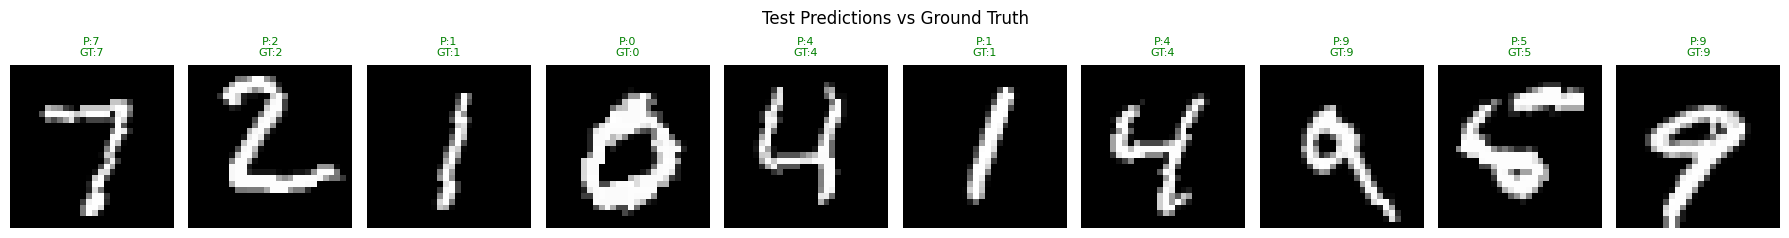

In [21]:
run_training_pipeline(config=training_config_mnist)

### KMNIST

Must have Accuracy ~91.09%
- 93.25% with channels (12, 24, 48)
- 91.34% with channels (8, 16, 32) epochs: 240 lr: 0.001 decay: 0.5 - 80

Training Configuration
model: KMNISTConvNet
number of parameters: 4917
dataset_name: KMNIST
epochs: 240
lr: 0.001
scheduler_params: {'step_size': 80, 'gamma': 0.5}
log_dir: runs
checkpoint_interval: 10
dnn_model: False
batch_size: 64
augment: False
[KMNIST] Epoch 1: Train Acc=0.6155, Val Acc=0.6160, LR=0.001
[KMNIST] Epoch 2: Train Acc=0.7959, Val Acc=0.6889, LR=0.001
[KMNIST] Epoch 3: Train Acc=0.8375, Val Acc=0.7392, LR=0.001
[KMNIST] Epoch 4: Train Acc=0.8588, Val Acc=0.7361, LR=0.001
[KMNIST] Epoch 5: Train Acc=0.8750, Val Acc=0.7689, LR=0.001
[KMNIST] Epoch 6: Train Acc=0.8865, Val Acc=0.7433, LR=0.001
[KMNIST] Epoch 7: Train Acc=0.8939, Val Acc=0.8032, LR=0.001
[KMNIST] Epoch 8: Train Acc=0.9001, Val Acc=0.8063, LR=0.001
[KMNIST] Epoch 9: Train Acc=0.9061, Val Acc=0.8078, LR=0.001
[KMNIST] Epoch 10: Train Acc=0.9110, Val Acc=0.8139, LR=0.001
📦 Saved model to epoch_10.pth with accuracy 0.8139
[KMNIST] Epoch 11: Train Acc=0.9141, Val Acc=0.8259, LR=0.001
[KMNIST] Epoch 12: Train Ac

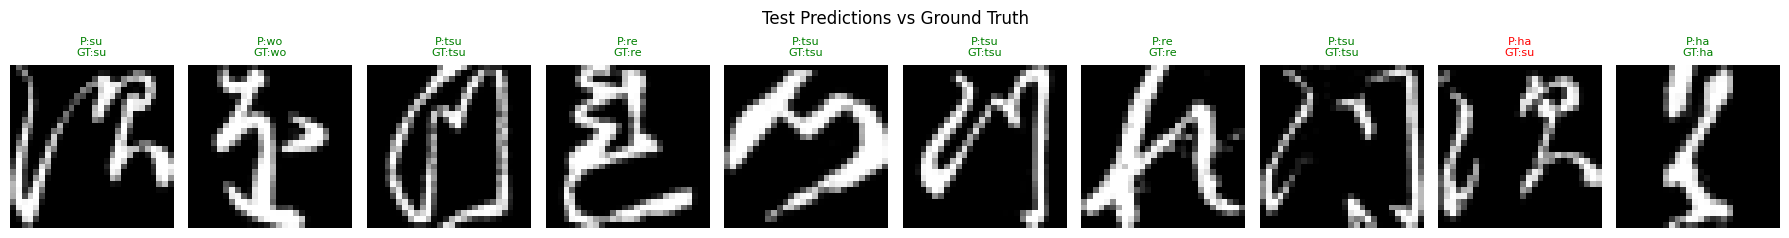

In [ ]:
# Create a training configuration object
training_config_kmnist = TrainingConfig(
    dataset_name="KMNIST",
    epochs=240,
    lr=0.001,
    scheduler_params={"step_size": 80, "gamma": 0.5},
    log_dir="runs",
    checkpoint_interval=10,
    dnn_model=False,  # Set to True to use DNN model
    batch_size=64,
    augment=False  # Set to True to apply data augmentation
)
run_training_pipeline(config=training_config_kmnist)

### FashionMNIST

In [40]:
# Create a training configuration object
training_config_fashionmnist = TrainingConfig(
    dataset_name="FashionMNIST",
    epochs=240,
    lr=0.001,
    scheduler_params={"step_size": 80, "gamma": 0.5},
    log_dir="runs",
    checkpoint_interval=10,
    dnn_model=False,  # Set to True to use DNN model
    batch_size=64,
    augment=False  # Set to True to apply data augmentation
)

Must have Accuracy ~88.69% 
- 89.72% epochs: 180 lr: 0.02 decay: 60 - 0.5 augment: False
- 90.00% epochs: 240 lr: 0.001 decay 80 - 0.5 augment: False

Training Configuration
model: FashionMNISTConvNet
number of parameters: 4917
dataset_name: FashionMNIST
epochs: 240
lr: 0.001
scheduler_params: {'step_size': 80, 'gamma': 0.5}
log_dir: runs
checkpoint_interval: 10
dnn_model: False
batch_size: 64
augment: False
[FashionMNIST] Epoch 1: Train Acc=0.6312, Val Acc=0.7578, LR=0.001
[FashionMNIST] Epoch 2: Train Acc=0.7933, Val Acc=0.8298, LR=0.001
[FashionMNIST] Epoch 3: Train Acc=0.8186, Val Acc=0.8328, LR=0.001
[FashionMNIST] Epoch 4: Train Acc=0.8315, Val Acc=0.8344, LR=0.001
[FashionMNIST] Epoch 5: Train Acc=0.8379, Val Acc=0.8246, LR=0.001
[FashionMNIST] Epoch 6: Train Acc=0.8430, Val Acc=0.8283, LR=0.001
[FashionMNIST] Epoch 7: Train Acc=0.8497, Val Acc=0.8544, LR=0.001
[FashionMNIST] Epoch 8: Train Acc=0.8516, Val Acc=0.8569, LR=0.001
[FashionMNIST] Epoch 9: Train Acc=0.8545, Val Acc=0.8590, LR=0.001
[FashionMNIST] Epoch 10: Train Acc=0.8603, Val Acc=0.8608, LR=0.001
📦 Saved model to epoch_10.pth with accuracy 0.8608
[FashionMNIST] Ep

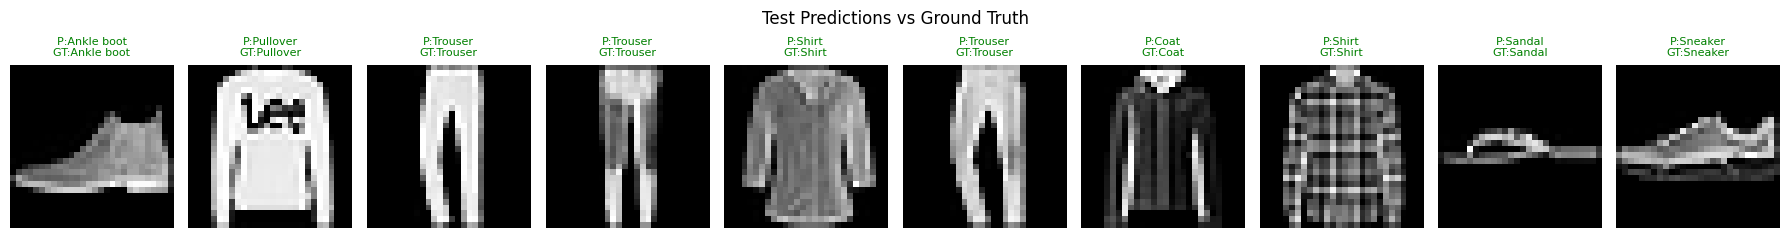

In [41]:
run_training_pipeline(config=training_config_fashionmnist)

### Tensorboard

In [26]:
import subprocess
import time
import webbrowser

In [27]:
def start_tensorboard(logdir="runs", port=6006):
    """
    Starts TensorBoard as a background process and opens it in your default browser.
    Returns the process handle so you can terminate it later.
    """
    tb_cmd = [
        "tensorboard",
        f"--logdir={logdir}",
        f"--port={port}",
        "--host=localhost"
    ]
    
    # Start the process
    print(f"Starting TensorBoard on port {port}...")
    process = subprocess.Popen(tb_cmd)
    
    # Give it a second to get going
    time.sleep(2)
    
    # Open in browser automatically
    url = f"http://localhost:{port}"
    print(f"Opening {url} in your default browser...")
    webbrowser.open(url)
    
    return process


def stop_tensorboard(process):
    """
    Stops the TensorBoard process started by `start_tensorboard()`.
    """
    print("Stopping TensorBoard...")
    process.terminate()  # or process.kill()


In [45]:
process = start_tensorboard(logdir="runs", port=6006)

Starting TensorBoard on port 6006...


TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

E0416 10:43:16.955830 140049025414976 program.py:300] TensorBoard could not bind to port 6006, it was already in use
ERROR: TensorBoard could not bind to port 6006, it was already in use


Opening http://localhost:6006 in your default browser...


In [29]:
stop_tensorboard(process)

Stopping TensorBoard...


In [42]:
# %load_ext tensorboard
# %tensorboard --logdir=runs

In [43]:
# %reload_ext tensorboard

In [44]:
# !kill 462979